In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

In [1]:
loan=pd.read_csv(r"..\cleanData\clean_loan.csv", sep=";")
loan

NameError: name 'pd' is not defined

In [ ]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   loan_id     682 non-null    int64         
 1   account_id  682 non-null    int64         
 2   date        682 non-null    datetime64[us]
 3   amount      682 non-null    float64       
 4   duration    682 non-null    int64         
 5   payments    682 non-null    float64       
 6   status      682 non-null    str           
 7   target      682 non-null    int64         
 8   is_closed   682 non-null    int64         
 9   year_month  682 non-null    period[M]     
dtypes: datetime64[us](1), float64(2), int64(5), period[M](1), str(1)
memory usage: 53.4 KB


In [ ]:
loan[["date","amount","duration","payments","target"]].describe()

,date,amount,duration,payments,target
count,682,682.000000,682.000000,682.000000,682.000000
mean,1996-09-29 05:35:43.108504,151410.175953,36.492669,4190.664223,0.111437
min,1993-07-05 00:00:00,4980.000000,12.000000,304.000000,0.000000
25%,1995-07-04 12:00:00,66732.000000,24.000000,2477.000000,0.000000
50%,1997-02-06 12:00:00,116928.000000,36.000000,3934.000000,0.000000
75%,1997-12-12 12:00:00,210654.000000,48.000000,5813.500000,0.000000
max,1998-12-08 00:00:00,590820.000000,60.000000,9910.000000,1.000000
std,NaN,113372.406310,17.075219,2215.830344,0.314903


In [ ]:
loan.describe(include='O')

C:\Users\saleh\AppData\Local\Temp\ipykernel_27684\3772433140.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  loan.describe(include='O')


,status
count,682
unique,4
top,C
freq,403


In [ ]:
loan.isnull().sum()

loan_id       0
account_id    0
date          0
amount        0
duration      0
payments      0
status        0
target        0
is_closed     0
year_month    0
dtype: int64

In [ ]:
loan.duplicated().sum()

np.int64(0)

In [ ]:
# ---------------------------------------------------------
# 1. Target Imbalance & Default Rate by Loan Status
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Target Class Distribution
sns.countplot(
    data=loan,
    x="target",
    palette=["#2b5c8f", "#d9534f"],
    ax=axes[0],
    hue="target",
    legend=False,
)
axes[0].set_title(
    "Target Imbalance (0 = Good, 1 = Default)", fontsize=12, fontweight="bold"
)
axes[0].set_xticklabels(["Performing (0)", "Default (1)"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Loans")
print(f" Percentage of Default Performing loans : {loan["target"].mean().round(3)*100}")
print(f" Percentage of Performing loans : {100-loan["target"].mean().round(3)*100}")

# ------------------------------------------------------------------
duration_risk = loan.groupby("duration")["target"].mean().reset_index()
sns.barplot(
    data=duration_risk,
    x="duration",
    y="target",
    palette="Reds_r",
    ax=axes[1],
    hue="duration",
    legend=False,
)
axes[1].set_title(
    "Default Rate Across Loan Terms (Months)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Loan Duration (Months)")
axes[1].set_ylabel("Default Rate (Proportion)")

for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f"{height:.2%}",
        (p.get_x() + p.get_width() / 2.0, height + 0.005),
        ha="center",
        va="bottom",
        fontweight="bold",
    )
# ---------------------------------------------------------
# 3. Risk Interaction: Loan Duration vs. Default Rate
# ---------------------------------------------------------
plt.figure(figsize=(9, 5))

duration_risk = (
    loan.groupby("duration")
    .agg(
        total_loans=("loan_id", "count"),
        default_rate=("target", "mean"),
        total_defaults=("target", "sum"),
    )
    .reset_index()
)

ax1 = sns.barplot(
    data=duration_risk,
    x="duration",
    y="total_loans",
    color="#2b5c8f",
    alpha=0.6,
    label="Total Loans Issued",
)
ax2 = ax1.twinx()
sns.lineplot(
    data=duration_risk,
    x=ax1.get_xticks(),
    y="default_rate",
    color="#d9534f",
    marker="o",
    linewidth=3,
    ax=ax2,
    label="Default Rate (%)",
)

ax1.set_title(
    "Loan Volume & Default Risk Across Term Durations",
    fontsize=12,
    fontweight="bold",
)
ax1.set_xlabel("Loan Duration (Months)")
ax1.set_ylabel("Number of Loans Issued")
ax2.set_ylabel("Default Rate", color="#d9534f")
ax2.grid(False)


# ---------------------------------------------------------
# 5. Feature Correlation Matrix
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
numeric_cols = ["amount", "duration", "payments", "target", "is_closed"]
corr = loan[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson Correlation"},
)
plt.title(
    "Numerical Correlation Matrix (`loan` features)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   loan_id              682 non-null    int64         
 1   account_id           682 non-null    int64         
 2   date                 682 non-null    datetime64[us]
 3   amount               682 non-null    float64       
 4   duration             682 non-null    int64         
 5   payments             682 non-null    float64       
 6   status               682 non-null    str           
 7   target               682 non-null    int64         
 8   is_closed            682 non-null    int64         
 9   year_month           682 non-null    period[M]     
 10  total_repayment_est  682 non-null    float64       
 11  interest_ratio       682 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(5), period[M](1), str(1)
memory usa

,loan_id,account_id,date,amount,duration,payments,target,is_closed,total_repayment_est,interest_ratio
count,682.000000,682.000000,682,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.0
mean,6172.466276,5824.162757,1996-09-29 05:35:43.108504,151410.175953,36.492669,4190.664223,0.111437,0.343109,151410.175953,1.0
min,4959.000000,2.000000,1993-07-05 00:00:00,4980.000000,12.000000,304.000000,0.000000,0.000000,4980.000000,1.0
25%,5577.500000,2967.000000,1995-07-04 12:00:00,66732.000000,24.000000,2477.000000,0.000000,0.000000,66732.000000,1.0
50%,6176.500000,5738.500000,1997-02-06 12:00:00,116928.000000,36.000000,3934.000000,0.000000,0.000000,116928.000000,1.0
75%,6752.500000,8686.000000,1997-12-12 12:00:00,210654.000000,48.000000,5813.500000,0.000000,1.000000,210654.000000,1.0
max,7308.000000,11362.000000,1998-12-08 00:00:00,590820.000000,60.000000,9910.000000,1.000000,1.000000,590820.000000,1.0
std,682.579279,3283.512681,NaN,113372.406310,17.075219,2215.830344,0.314903,0.475096,113372.406310,0.0



=== Categorical Summary Statistics ===


C:\Users\saleh\AppData\Local\Temp\ipykernel_27684\2652883513.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(loan.describe(include="O"))


,status
count,682
unique,4
top,C
freq,403



=== Missing Values Count ===
loan_id                0
account_id             0
date                   0
amount                 0
duration               0
payments               0
status                 0
target                 0
is_closed              0
year_month             0
total_repayment_est    0
interest_ratio         0
dtype: int64

=== Duplicate Rows Count ===
Duplicates: 0


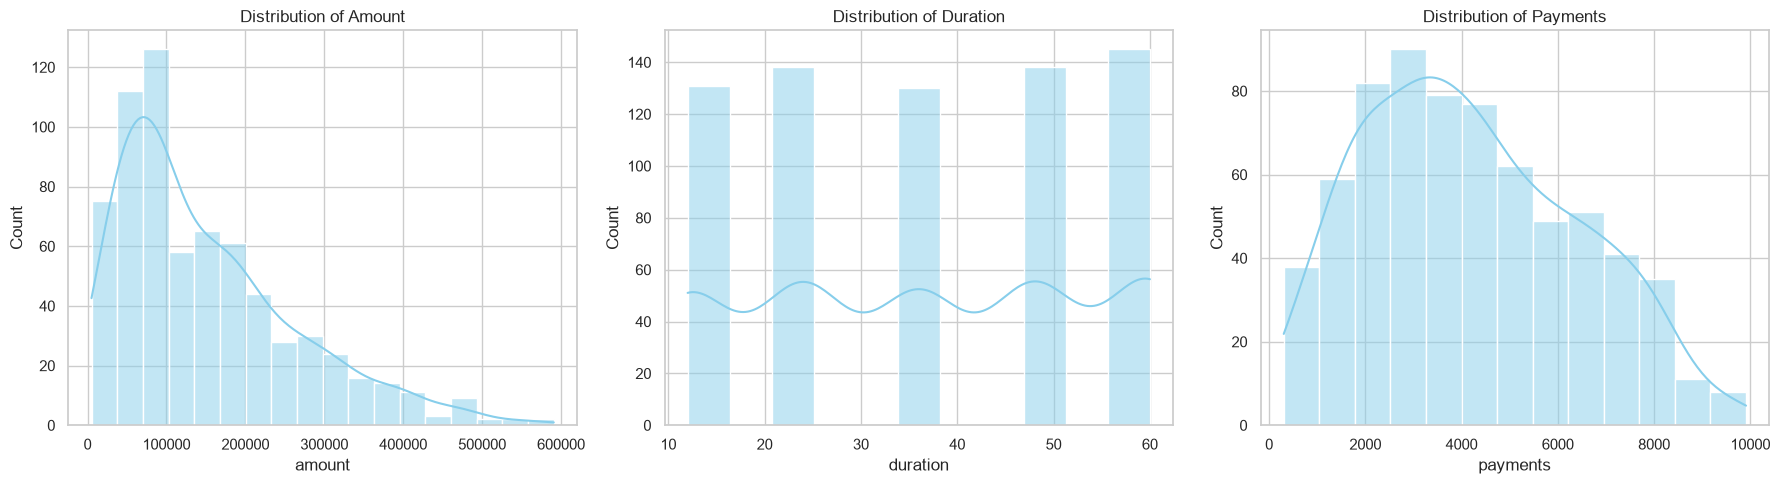

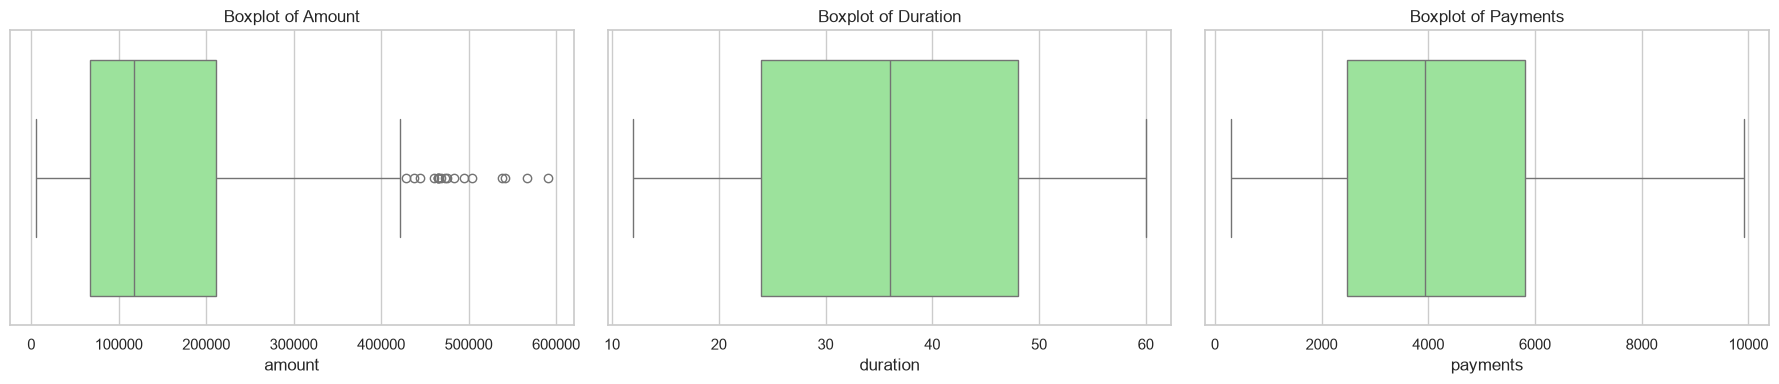

C:\Users\saleh\AppData\Local\Temp\ipykernel_27684\2652883513.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=loan, ax=axes[i], palette="Set2")
C:\Users\saleh\AppData\Local\Temp\ipykernel_27684\2652883513.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=loan, ax=axes[i], palette="Set2")
C:\Users\saleh\AppData\Local\Temp\ipykernel_27684\2652883513.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=loan, ax=axes[i], palette="Set2")


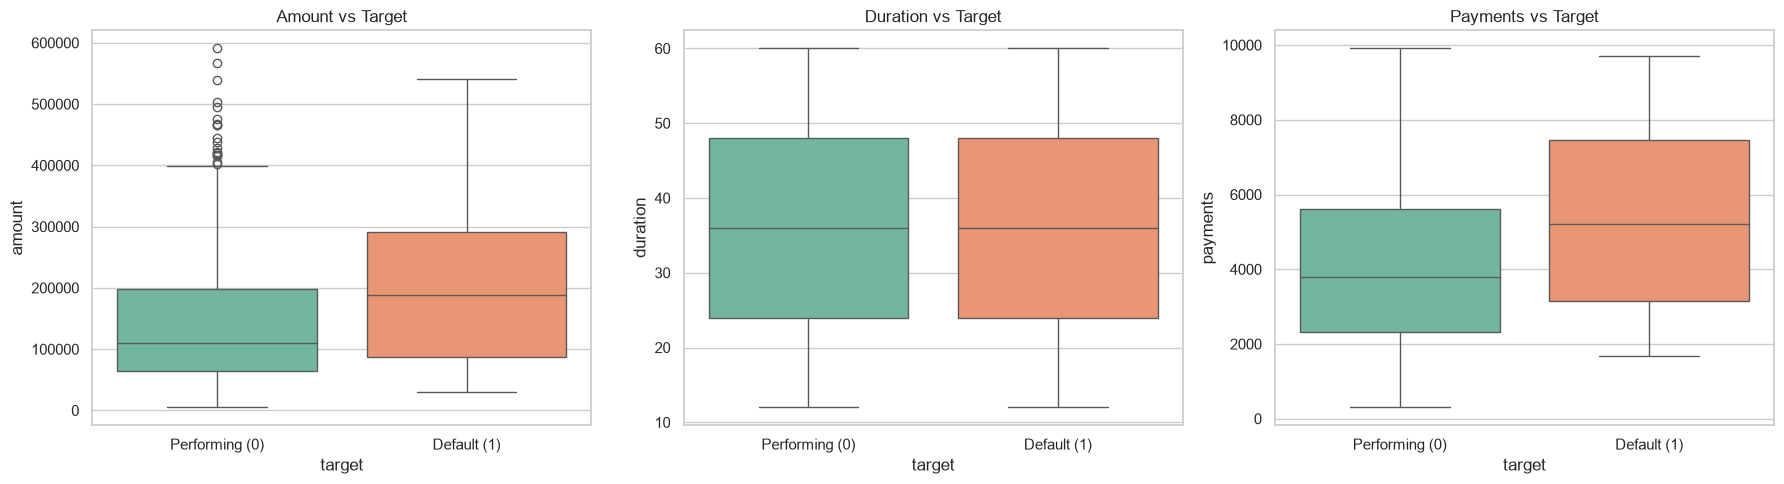

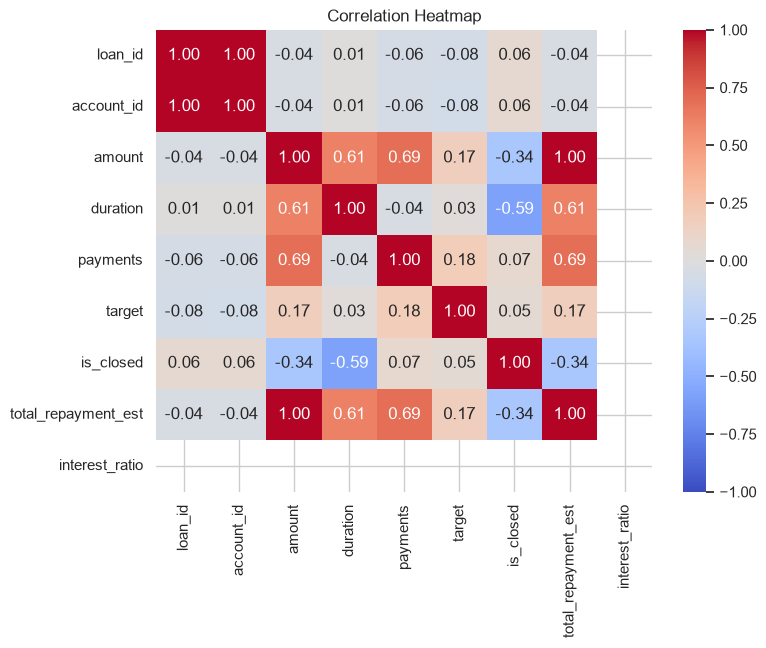

In [ ]:


# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# -------------------------------------------------------------------------
# 1. INITIAL DATA HEALTH & STRUCTURE CHECKS
# -------------------------------------------------------------------------
print("=== Dataset Information ===")
print(loan.info())

print("\n=== Numerical Summary Statistics ===")
display(loan.describe())

print("\n=== Categorical Summary Statistics ===")
display(loan.describe(include="O"))

print("\n=== Missing Values Count ===")
print(loan.isnull().sum())

print("\n=== Duplicate Rows Count ===")
print(f"Duplicates: {loan.duplicated().sum()}")


# -------------------------------------------------------------------------
# 2. UNIVARIATE ANALYSIS (INDIVIDUAL COLUMNS)
# -------------------------------------------------------------------------
# Ensure 'date' is properly formatted as datetime
if "date" in loan.columns and not pd.api.types.is_datetime64_any_dtype(
    loan["date"]
):
  loan["date"] = pd.to_datetime(loan["date"])

num_cols = ["amount", "duration", "payments"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
  if col in loan.columns:
    sns.histplot(loan[col], kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {col.capitalize()}")

plt.tight_layout()
plt.show()

# Boxplots for Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(num_cols):
  if col in loan.columns:
    sns.boxplot(x=loan[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(f"Boxplot of {col.capitalize()}")

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# 3. BIVARIATE & MULTIVARIATE ANALYSIS
# -------------------------------------------------------------------------
if "target" in loan.columns:
  # Feature vs Target Distributions
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))

  for i, col in enumerate(num_cols):
    if col in loan.columns:
      sns.boxplot(x="target", y=col, data=loan, ax=axes[i], palette="Set2")
      axes[i].set_xticks([0, 1])
      axes[i].set_xticklabels(["Performing (0)", "Default (1)"])
      axes[i].set_title(f"{col.capitalize()} vs Target")

  plt.tight_layout()
  plt.show()

# Feature Ratios & Implied Total Repayment
if "duration" in loan.columns and "payments" in loan.columns:
  loan["total_repayment_est"] = loan["duration"] * loan["payments"]
  if "amount" in loan.columns:
    loan["interest_ratio"] = loan["total_repayment_est"] / loan["amount"]

# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = loan.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()




In [ ]:
loan.head()

,loan_id,account_id,date,amount,duration,payments,status,target,is_closed,year_month,total_repayment_est,interest_ratio
0,5314,1787,1993-07-05,96396.0,12,8033.0,B,1,1,1993-07,96396.0,1.0
1,5316,1801,1993-07-11,165960.0,36,4610.0,A,0,1,1993-07,165960.0,1.0
2,6863,9188,1993-07-28,127080.0,60,2118.0,A,0,1,1993-07,127080.0,1.0
3,5325,1843,1993-08-03,105804.0,36,2939.0,A,0,1,1993-08,105804.0,1.0
4,7240,11013,1993-09-06,274740.0,60,4579.0,A,0,1,1993-09,274740.0,1.0


# Executive & Technical Summary: Credit Risk & Loan Default Analysis

---

## Key Findings & Technical Actions

### 1. Severe Class Imbalance & Evaluation Strategy
> **Class Imbalance:** 88.9% Performing vs. 11.1% Default

* **Business Insight:** Defaults are relatively rare events (~1 out of 9 borrowers default). However, default loss severity is asymmetric—approving a bad loan costs the bank the full principal, whereas rejecting a good loan costs only missed interest.
* **Technical Actions:**
  - [x] Reject raw **Accuracy** as an optimization metric.
  - [x] Track **PR-AUC**, **ROC-AUC**, and **Default Recall ($y=1$)** to evaluate true default capture.
  - [x] Implement cost-sensitive learning (`class_weight='balanced'`) and resampling techniques (e.g., SMOTE) during baseline model training.

---

### 2. Monthly Debt Burden vs. Loan Term Length
* **Business Insight:** Monthly payment amount is the strongest risk indicator ($r = 0.18$). Defaulted borrowers face a significantly higher median monthly payment (~$5,200) than performing borrowers (~$3,800). Extending loan duration beyond 12 months shows almost zero linear correlation with default risk ($r = 0.03$), with default rates flatlining around ~11.5%–12.3% across 24 to 60-month terms.
* **Technical Actions:**
  - [x] Focus feature engineering on liquidity ratios (e.g., **Payment-to-Amount Ratio** $\frac{\text{payments}}{\text{amount}}$) rather than raw term length.

---

### 3. Principal Exposure & Data Transformations
* **Business Insight:** Defaulted loans carry higher median loan amounts (~$190,000) than non-defaulting loans (~$110,000). The principal distribution is right-skewed with extreme high-exposure tails extending up to $590,000.
* **Technical Actions:**
  - [x] **Do not drop high-amount outliers**, as they represent real high-severity financial exposure.
  - [x] Apply log transformations ($\log(1 + x)$) or robust scaling to handle extreme upper tails for linear and distance-based algorithms.

---

### 4. Multicollinearity & Strict Target Leakage Exclusion
* **Business Insight:** Including post-approval fields or redundant tracking IDs will artificially inflate model performance during development and fail in production inference.
* **Technical Actions:**
  - [x] **Target Leakage Exclusion:** Strictly drop `status` (codes A, B, C, D) and `is_closed` from the feature matrix $X$ prior to model fitting, as status directly encodes default outcomes.
  - [x] **Multicollinearity Removal:** Drop `account_id` (perfectly collinear with `loan_id`, $r = 1.00$) and `total_repayment_est` (perfectly collinear with `amount`, $r = 1.00$.
  - [x] **Pipeline Cleanup:** Fix zero-division and constant value errors in engineered features (e.g., `interest_ratio` yielding `NaN` values).

